In [1]:
import numpy as np
import matplotlib.pyplot as plt
import rasterio
from rasterio.transform import from_origin
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, cohen_kappa_score
)
import joblib
from pathlib import Path

print("All imports OK")

All imports OK


In [2]:
# Image size
H, W = 200, 200

# Simulate 6 spectral bands (like B2,B3,B4,B8,B11,B12)
rng = np.random.default_rng(42)

# Create a simple pattern: 3 horizontal zones = 3 land-cover classes
# class 0: agriculture (top), class 1: built-up (middle), class 2: forest (bottom)
true_labels = np.zeros((H, W), dtype=np.uint8)
true_labels[0:70, :] = 0       # agriculture
true_labels[70:140, :] = 1     # built-up
true_labels[140:, :] = 2       # forest

# Generate band values with some class-dependent signal + noise
def make_band(base_vals, noise_std=0.05):
    band = np.zeros((H, W), dtype=np.float32)
    for cls in range(3):
        mask = (true_labels == cls)
        band[mask] = base_vals[cls] + rng.normal(0, noise_std, size=mask.sum())
    return np.clip(band, 0, 1)

b2  = make_band([0.10, 0.20, 0.05])
b3  = make_band([0.12, 0.22, 0.06])
b4  = make_band([0.15, 0.25, 0.07])
b8  = make_band([0.45, 0.30, 0.55])
b11 = make_band([0.25, 0.35, 0.20])
b12 = make_band([0.15, 0.25, 0.12])

# Stack as (H, W, 6)
stack = np.stack([b2, b3, b4, b8, b11, b12], axis=-1)

# Define a fake geotransform and CRS for saving
transform = from_origin(0, W, 10, 10)  # arbitrary
crs = "EPSG:4326"

print("Synthetic raster created, shape:", stack.shape)

Synthetic raster created, shape: (200, 200, 6)


In [3]:
out_dir = Path("../data/raw")
out_dir.mkdir(parents=True, exist_ok=True)

out_path = out_dir / "synthetic_scene.tif"

profile = {
    "driver": "GTiff",
    "height": H,
    "width": W,
    "count": stack.shape[-1],
    "dtype": "float32",
    "crs": crs,
    "transform": transform,
}

with rasterio.open(out_path, "w", **profile) as dst:
    for i in range(stack.shape[-1]):
        dst.write(stack[..., i], i + 1)

print("Saved synthetic scene to:", out_path)

Saved synthetic scene to: ..\data\raw\synthetic_scene.tif


In [4]:
# Flatten
X = stack.reshape(-1, stack.shape[-1])  # (H*W, 6)
y = true_labels.reshape(-1)             # (H*W,)

# Subsample to keep it fast
n_samples = 5000
idxs = rng.choice(len(y), size=n_samples, replace=False)

X_sub = X[idxs]
y_sub = y[idxs]

print("Training data shape:", X_sub.shape, y_sub.shape)

Training data shape: (5000, 6) (5000,)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X_sub, y_sub, test_size=0.2, random_state=42, stratify=y_sub
)

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    n_jobs=-1,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
kappa = cohen_kappa_score(y_test, y_pred)

print("Overall accuracy:", acc)
print("Kappa:", kappa)
print("\nClassification report:\n", classification_report(y_test, y_pred))

Overall accuracy: 0.956
Kappa: 0.933873963774955

Classification report:
               precision    recall  f1-score   support

           0       0.94      0.93      0.94       346
           1       1.00      0.99      1.00       353
           2       0.92      0.94      0.93       301

    accuracy                           0.96      1000
   macro avg       0.95      0.96      0.95      1000
weighted avg       0.96      0.96      0.96      1000



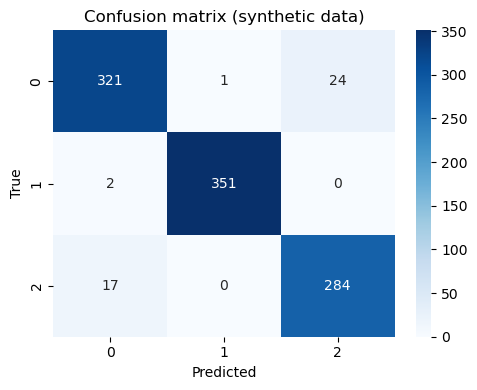

In [6]:
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion matrix (synthetic data)")
plt.tight_layout()
plt.show()

In [7]:
# Predict for all pixels
X_full = stack.reshape(-1, stack.shape[-1])
pred_full = rf.predict(X_full).reshape(H, W).astype("uint8")

# Save classified map
maps_dir = Path("../outputs/maps")
maps_dir.mkdir(parents=True, exist_ok=True)

out_cls_path = maps_dir / "synthetic_lulc.tif"

profile_cls = {
    "driver": "GTiff",
    "height": H,
    "width": W,
    "count": 1,
    "dtype": "uint8",
    "crs": crs,
    "transform": transform,
    "compress": "lzw",
}

with rasterio.open(out_cls_path, "w", **profile_cls) as dst:
    dst.write(pred_full, 1)

print("Saved classified map to:", out_cls_path)

Saved classified map to: ..\outputs\maps\synthetic_lulc.tif


In [8]:
unique, counts = np.unique(pred_full, return_counts=True)
total_pixels = pred_full.size

stats = []
for cls_id, cnt in zip(unique, counts):
    pct = cnt / total_pixels * 100
    stats.append({"class_id": int(cls_id), "pixel_count": int(cnt), "percentage": round(pct, 2)})

import pandas as pd
df_stats = pd.DataFrame(stats)

# Add class names for this synthetic example
class_names = {
    0: "agriculture",
    1: "built_up",
    2: "forest"
}
df_stats["class_name"] = df_stats["class_id"].map(class_names)

df_stats

,class_id,pixel_count,percentage,class_name
0,0,14085,35.21,agriculture
1,1,13988,34.97,built_up
2,2,11927,29.82,forest


In [9]:
models_dir = Path("../models")
models_dir.mkdir(parents=True, exist_ok=True)

model_path = models_dir / "rf_synthetic.pkl"
joblib.dump(rf, model_path)

print("Model saved to:", model_path)

Model saved to: ..\models\rf_synthetic.pkl
